In [32]:
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import os

In [33]:
dataset = "./olivetti_faces/"

In [34]:
#load images

def load_images(path):

    X = []
    y = []

    if os.path.exists(path) == False:
        print("Dataset not found")
        return None

    for folder in os.listdir(path):
        for item in os.listdir(path + folder):
            if item.endswith(".png") or item.endswith(".jpg"):
                X.append(np.asarray(Image.open(path + folder + "/" + item))) #immagine in bianco e nero
                y.append(folder) #label

    return np.asarray(X), np.asarray(y)

X, y = load_images(dataset)

400
<class 'numpy.ndarray'>


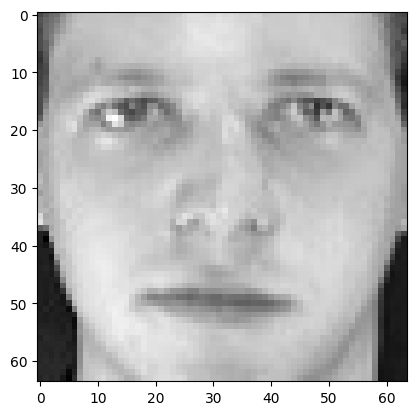

In [35]:
print(len(X))
print(type(X[0]))

plt.imshow(X[0], cmap='gray')
plt.show()

In [36]:
print(len(y))
print(type(y[0]))
print(y)
y.shape

400
<class 'numpy.str_'>
['0' '0' '0' '0' '0' '0' '0' '0' '0' '0' '1' '1' '1' '1' '1' '1' '1' '1'
 '1' '1' '10' '10' '10' '10' '10' '10' '10' '10' '10' '10' '11' '11' '11'
 '11' '11' '11' '11' '11' '11' '11' '12' '12' '12' '12' '12' '12' '12'
 '12' '12' '12' '13' '13' '13' '13' '13' '13' '13' '13' '13' '13' '14'
 '14' '14' '14' '14' '14' '14' '14' '14' '14' '15' '15' '15' '15' '15'
 '15' '15' '15' '15' '15' '16' '16' '16' '16' '16' '16' '16' '16' '16'
 '16' '17' '17' '17' '17' '17' '17' '17' '17' '17' '17' '18' '18' '18'
 '18' '18' '18' '18' '18' '18' '18' '19' '19' '19' '19' '19' '19' '19'
 '19' '19' '19' '2' '2' '2' '2' '2' '2' '2' '2' '2' '2' '20' '20' '20'
 '20' '20' '20' '20' '20' '20' '20' '21' '21' '21' '21' '21' '21' '21'
 '21' '21' '21' '22' '22' '22' '22' '22' '22' '22' '22' '22' '22' '23'
 '23' '23' '23' '23' '23' '23' '23' '23' '23' '24' '24' '24' '24' '24'
 '24' '24' '24' '24' '24' '25' '25' '25' '25' '25' '25' '25' '25' '25'
 '25' '26' '26' '26' '26' '26' '26' '26' '26' '

(400,)

In [37]:
X = X.reshape(X.shape[0], X.shape[1]*X.shape[2]) #flatten images
X.shape

(400, 4096)

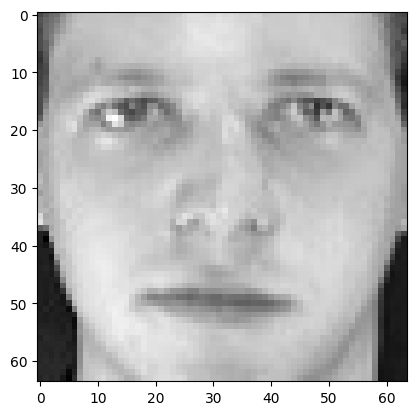

In [30]:
plt.imshow(X[0].reshape(64, 64), cmap='gray') #inverse transformation
plt.show()

In [38]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2) #split dataset in train and test set

In [39]:
#normalize images

X_train = X_train / 255.0
X_test = X_test / 255.0

In [40]:
np.isin(y_test, y_train) #check if there are common labels in train and test set

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True])

In [41]:
#train KNN classifier

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

search_grid = [1, 3, 5, 7, 9, 11, 13, 15] #number of neighbors
best_accuracy = 0

best_k = 0
best_model = None

for k in search_grid:
    knn = KNeighborsClassifier(n_neighbors=k, n_jobs=-1) #create KNN classifier
    knn.fit(X_train, y_train) #train classifier
    y_pred = knn.predict(X_test) #predict labels

    accuracy = accuracy_score(y_test, y_pred) #calculate accuracy

    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_k = k
        best_model = knn

knn = KNeighborsClassifier(n_neighbors=best_k, n_jobs=-1) #create KNN classifier
knn.fit(X_train, y_train) #train classifier
y_pred = knn.predict(X_test) #predict labels

accuracy = accuracy_score(y_test, y_pred) #calculate accuracy
print("Accuracy: ", accuracy)
print(classification_report(y_test, y_pred)) #print classification report


Accuracy:  0.9375
              precision    recall  f1-score   support

           0       1.00      0.33      0.50         3
           1       1.00      1.00      1.00         1
          10       1.00      1.00      1.00         2
          11       1.00      1.00      1.00         2
          12       1.00      1.00      1.00         3
          13       1.00      1.00      1.00         1
          14       0.50      1.00      0.67         1
          15       1.00      1.00      1.00         1
          16       1.00      1.00      1.00         4
          17       1.00      1.00      1.00         1
          19       1.00      1.00      1.00         2
           2       0.67      1.00      0.80         2
          20       1.00      1.00      1.00         2
          21       1.00      0.67      0.80         3
          22       1.00      1.00      1.00         3
          23       1.00      1.00      1.00         3
          24       1.00      1.00      1.00         4
         

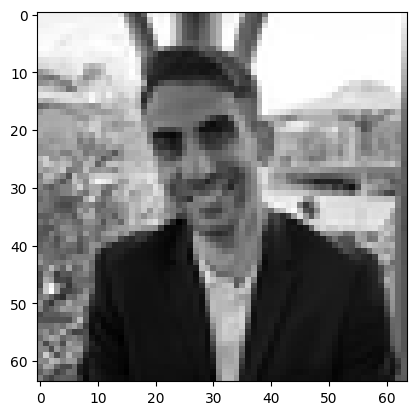

In [71]:
test_image = np.asarray(
        Image.open("./test_faces/test.jpg").convert("L").resize((64, 64), Image.Resampling.LANCZOS) #load and resize test image
    ).reshape(64 * 64) # flatten image

image_to_test = test_image
plt.imshow(image_to_test.reshape(64, 64), cmap='gray')
plt.show()

In [67]:
test_image = test_image / 255.0 #normalize image

In [70]:
prediction = knn.predict([test_image])

prediction

array(['25'], dtype='<U2')